### Steps 2+3 Model

- Use Deterministic Opinf
- Fit Bayesian GP & Operator Jointly

In [1]:
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("../")

import os
import h5py
import numpy as np

import opinf

import config
import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt
from things.bgp_jax import BayesianGP
import jax.numpy as jnp
import jax

Logging to log.log


INFO:2025-06-20 17:03:15,993:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/anthonypoole/miniconda3/envs/prob_rom/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


#### Generate Noisy Data

In [2]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [3]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.38 s.


reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.04 s.
Weight matrix None
Off diagonal loss 3.284699e-15


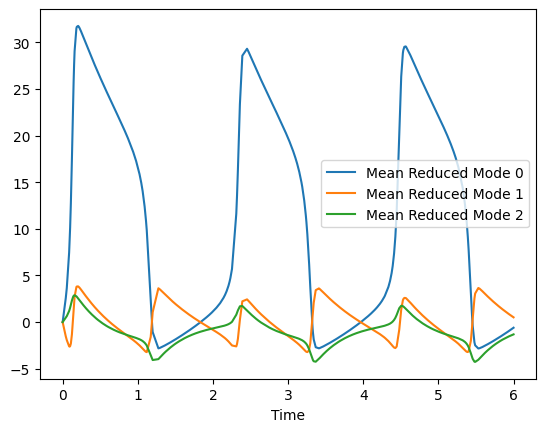

In [4]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

V = basis.entries
W = basis.weights
print(f'Weight matrix', W)

off_diagonal_loss = jnp.sum((V.T @ V) - jnp.eye(V.shape[1])**2)
print("Off diagonal loss", off_diagonal_loss)

for i in range(numPODmodes):
    plt.plot(time_domain_sampled, snapshots_compressed[i], label = f"Mean Reduced Mode {i}")
plt.xlabel('Time')
plt.legend()

In [5]:
from jax.scipy.special import gammaln

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

(512, 400) (512, 400)
idk man


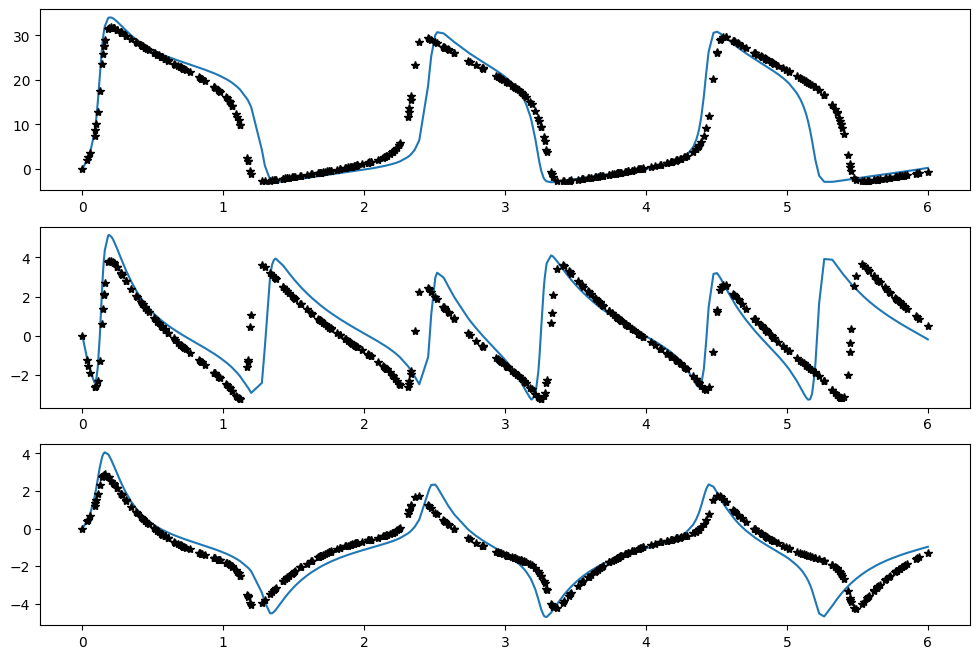

In [6]:
import numpy as np
import random
import time
import opinf

### Generate Prior For operator matrix
input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) 

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    model=JaxCompatibleModel(
        operators="cAHBN",
        solver=opinf.lstsq.L2Solver(regularizer=1e-6),
    )
).fit(states=snapshots_sampled, inputs=inputs)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain, input_func=input_func)
prior_ohat = rom.model.operator_matrix

# Put the operator in the ROM
rom.model._extract_operators(np.array(prior_ohat))

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
    input_func=input_func
)
deter_sol = rom.model.predict_result_
# print(deter_sol.ts.shape)          
# print(deter_sol.message) 

if deter_sol.t.shape[0] == snapshots_sampled.shape[1]:
    print("idk man")
else:
    print(deter_sol.t.shape[0], snapshots_compressed.shape, sep='\n')
    print("Failed to find stable operator, retry")

fig, ax = plt.subplots(3,1, figsize = (12, 8))

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

#### Fit Bayesian GP to the compressed snapshots

In [7]:
# K_yys = jnp.stack([gp.get_kernel_matrix(time_domain_sampled, nugget=1e-4) for gp in gps])
# K_zys = jnp.stack([gp.get_kernel_derivative_dt1(time_domain_sampled) for gp in gps])
# K_zzs = jnp.stack([gp.get_kernel_double_derivative(time_domain_sampled) for gp in gps])
# noise_vars = jnp.array([gp.hyperparameters["noise"] for gp in gps])[:, None]*jnp.ones(time_domain_sampled.size)
# sigma_zi = jnp.array([gp.get_As(time_domain_sampled)[0] for gp in gps])
# Ds = jnp.stack([
#     # gp.get_kernel_derivative_dt1(time) already does get_dash_c_phi(self.params, time)
#     gp.get_kernel_derivative_dt1(time_domain_sampled) @ jnp.linalg.solve(K_yys[idx], jnp.eye(time_domain_sampled.shape[0]))
#     for idx, gp in enumerate(gps)
# ])

In [8]:
# import numpyro
# import jax.numpy as jnp
# import numpyro.distributions as dist
# from numpyro.infer import NUTS, MCMC
# from things.bgp_jax import RBFKernel

# kernel = RBFKernel()

# def model(time, qhat, normalization=1e-4):
#     num_time_steps = time.shape[0]
     
#     xs = []
#     ys = []
#     for i in range(numPODmodes):
#         # Priors for hyperparameters
#         lengthscale = numpyro.sample(f"lengthscale{i}", dist.LogNormal(0.0, 1.0))
#         variance = numpyro.sample(f"variance{i}", dist.LogNormal(0.0, 1.0))
#         noise = numpyro.sample(f"noise{i}", dist.LogNormal(-2.0, 1.0))
        
#         # Compute kernel matrix
#         K = kernel(time,time, lengthscale, variance)
        
#         # Add noise to diagonal for numerical stability and observation noise
#         K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
#         # GP prior over function values
#         x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
#         # Likelihood
#         with numpyro.plate(f"data{i}", num_time_steps):
#             numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])
    
#     xs = jnp.array(xs)

# rng_key = jax.random.PRNGKey(42)
    
# # Initialize NUTS sampler
# nuts_kernel = NUTS(model)

# # Run MCMC
# mcmc = MCMC(
#     nuts_kernel, 
#     num_samples=100, 
#     num_warmup=50,
#     progress_bar=True
# )

# mcmc.run(rng_key, 
#         time = time_domain_sampled[:, None], 
#         qhat = snapshots_compressed,
# )
         

# # Store samples
# samples = mcmc.get_samples()

# print(f"\nMCMC completed with {num_samples} samples")

In [ ]:
import numpyro
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from things.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()

def model(time, qhat, O_mean, chi, normalization=1e-4):
    num_time_steps = time.shape[0]

    # Operator sample
    # Shape (3,14)
    O = numpyro.sample('oi', 
                        dist.Normal(O_mean, jnp.ones_like(O_mean)*(.001))) # .001
     
    Xs = []
    Ls = []
    Vars = []
    noises = []
    Kyys = []
    for i in range(numPODmodes):
        # Priors for hyperparameters
        lengthscale = numpyro.sample(f"lengthscale{i}", dist.LogNormal(0.0, 1.0))
        Ls.append(lengthscale)
        variance = numpyro.sample(f"variance{i}", dist.LogNormal(0.0, 1.0))
        Vars.append(variance)
        noise = numpyro.sample(f"noise{i}", dist.LogNormal(-2.0, 1.0))
        noises.append(noise)
        
        # Compute kernel matrix
        K = kernel(time,time, lengthscale, variance)
        
        # Add noise to diagonal for numerical stability and observation noise
        K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
        # GP prior over function values
        x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
        # Likelihood
        with numpyro.plate(f"data{i}", num_time_steps):
            numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])
    
        ### Now gradient matching part
    
        # Sample Xi for all modes - this is the key fix
        Kyy = get_c_phi(lengthscale, variance, time, normalization)
        Kyys.append(Kyy)
        Xi = numpyro.sample(f'Xi{i}',
                            dist.MultivariateNormal(
                                jnp.zeros(num_time_steps),
                                Kyy 
                            ))  
        Xs.append(Xi)
        
        obs_cov = chi * jnp.eye(num_time_steps)
        
        numpyro.sample(f'Yi{i}',
                    dist.MultivariateNormal(Xi, obs_cov),
                    obs=qhat[i])
        
    Xs = jnp.array(Xs)
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs) @ O.T

    for i in range(numPODmodes):
        lengthscale = Ls[i]
        variance = Vars[i]
        Kyy = Kyys[i]
        Ds = get_dash_c_phi(lengthscale, variance, time) @ jnp.linalg.solve(Kyy, jnp.eye(num_time_steps))

        CDashs = get_c_phi_dash(lengthscale, variance, time)
        DashCs = get_dash_c_phi(lengthscale, variance, time)
        CPhis = get_c_phi(lengthscale, variance, time, nugget=1e-4)
        CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
        A = CDoubleDashs - jnp.dot(DashCs, jnp.linalg.solve(CPhis, CDashs))

        mu_zi = Ds @ Xi

        gamma = 1e2*[5,1,1][i]
        constraint_cov = A + gamma * jnp.eye(num_time_steps)
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

rng_key = jax.random.PRNGKey(42)
    
# Initialize NUTS sampler
nuts_kernel = NUTS(model)

# Run MCMC
mcmc = MCMC(
    nuts_kernel, 
    num_samples=100, 
    num_warmup=50,
    progress_bar=True
)

mcmc.run(rng_key, 
        time = time_domain_sampled[:, None], 
        qhat = snapshots_compressed,
        O_mean = prior_ohat,
        chi = 1e-6,
)
         

# Store samples
samples = mcmc.get_samples()

print(f"\nMCMC completed with {num_samples} samples")

sample: 100%|██████████| 150/150 [1:10:54<00:00, 28.36s/it, 1023 steps of size 4.17e-08. acc. prob=0.76]


MCMC completed with 400 samples


In [23]:
mean_oi = samples['oi'].mean(axis=0)
median_oi = jnp.median(samples['oi'], axis=0)
mean_oi.shape, median_oi

((3, 14),
 Array([[ 5.74923859e+01, -1.68264561e+01, -4.21168232e+00,
          5.05511398e+01,  7.06244111e-01, -4.79032660e+00,
         -1.82569551e+00,  3.29406548e+00, -1.98501205e+00,
          1.01603603e+00, -1.86774147e+00,  9.10836160e-02,
         -8.45809951e-02, -3.26544702e-01],
        [-4.22122917e+01,  3.13267684e+00, -2.08768291e+01,
         -3.45508232e+01, -2.75716819e-02, -3.01039845e-01,
         -6.40771151e+00,  3.25715423e+00, -1.17146671e+00,
          1.00472510e+00,  2.97266871e-01, -5.11431135e-03,
          8.29898193e-02, -2.01429307e-01],
        [ 1.11237087e+01,  2.11767941e+01,  3.17786465e+01,
          7.60815525e+00, -9.13805246e-01,  1.08736277e+00,
          1.99979562e-02, -5.35864294e-01,  3.68280411e-02,
         -2.16808930e-01, -2.08400297e+00,  1.03217416e-01,
         -2.75886297e-01, -3.95429060e-02]], dtype=float32))

In [24]:
mean_oi

Array([[ 5.7492390e+01, -1.6826454e+01, -4.2116828e+00,  5.0551140e+01,
         7.0624411e-01, -4.7903271e+00, -1.8256952e+00,  3.2940664e+00,
        -1.9850122e+00,  1.0160364e+00, -1.8677409e+00,  9.1083698e-02,
        -8.4579870e-02, -3.2654470e-01],
       [-4.2212284e+01,  3.1326761e+00, -2.0876827e+01, -3.4550823e+01,
        -2.7571766e-02, -3.0103981e-01, -6.4077134e+00,  3.2571537e+00,
        -1.1714667e+00,  1.0047250e+00,  2.9726002e-01, -5.1156371e-03,
         8.2990266e-02, -2.0142934e-01],
       [ 1.1123708e+01,  2.1176796e+01,  3.1778643e+01,  7.6081548e+00,
        -9.1380507e-01,  1.0873625e+00,  1.9998260e-02, -5.3586632e-01,
         3.6828365e-02, -2.1680307e-01, -2.0840032e+00,  1.0321718e-01,
        -2.7589092e-01, -3.9543353e-02]], dtype=float32)

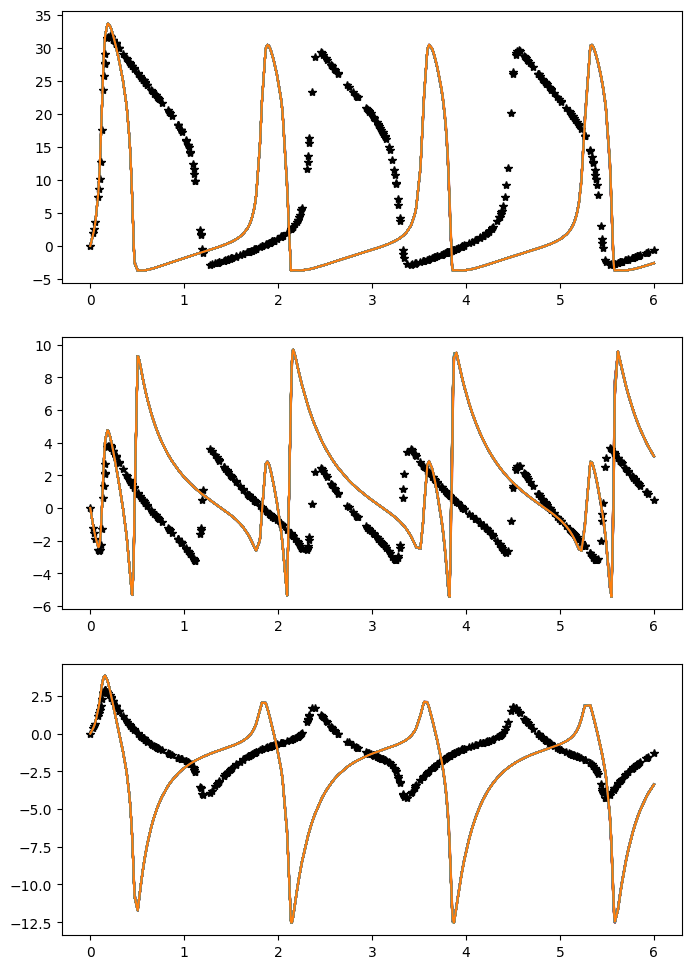

In [26]:
import random

fig, ax = plt.subplots(3,1, figsize = (8, 12))

num_pulls = 50
for i in range(num_pulls):
    rand_idx = random.randint(0, len(samples['oi']))
    o = samples['oi'][rand_idx]
    # Put the operator in the ROM
    rom.model._extract_operators(np.array(o))

    # Plot predictions within training time domains
    deter_pred = rom.model.predict(
        state0=snapshots_compressed[:, 0], 
        t=time_domain_sampled, 
        input_func=input_func
    )
    deter_sol = rom.model.predict_result_
    # print(deter_sol.ts.shape)          
    # print(deter_sol.message) 

    if deter_sol.t.shape[0] == snapshots_sampled.shape[1]:
        pass
    else:
        print(deter_sol.t.shape[0], snapshots_compressed.shape, sep='\n')
        print("Failed to find stable operator, retry")

    for i in range(numPODmodes):
        ax[i].plot(deter_sol.t, deter_sol.y[i])

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')


rom.model._extract_operators(np.array(mean_oi))
deter_pred = rom.model.predict(
        state0=snapshots_compressed[:, 0], 
        t=time_domain_sampled, 
        input_func=input_func
    )
deter_sol = rom.model.predict_result_

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])

rom.model._extract_operators(np.array(median_oi))
deter_pred = rom.model.predict(
        state0=snapshots_compressed[:, 0], 
        t=time_domain_sampled, 
        input_func=input_func
    )
deter_sol = rom.model.predict_result_

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])